In [ ]:
import zipfile
import os

zip_path = "/content/archive.zip"

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("Extraction Done")

Extraction Done


In [ ]:
os.listdir("/content/data")

['EEG Eye State.arff', 'EEG_Eye_State_Classification.csv']

In [ ]:
import pandas as pd

file_path = "/content/data/EEG_Eye_State_Classification.csv"

df = pd.read_csv(file_path)

df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [ ]:
df.shape

(14980, 15)

In [ ]:
df.columns

Index(['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6',
       'F4', 'F8', 'AF4', 'eyeDetection'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   F7            14980 non-null  float64
 2   F3            14980 non-null  float64
 3   FC5           14980 non-null  float64
 4   T7            14980 non-null  float64
 5   P7            14980 non-null  float64
 6   O1            14980 non-null  float64
 7   O2            14980 non-null  float64
 8   P8            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  FC6           14980 non-null  float64
 11  F4            14980 non-null  float64
 12  F8            14980 non-null  float64
 13  AF4           14980 non-null  float64
 14  eyeDetection  14980 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 1.7 MB


In [ ]:
df.isnull().sum()

,0
AF3,0
F7,0
F3,0
FC5,0
T7,0
P7,0
O1,0
O2,0
P8,0
T8,0


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
# Split Features and Labels
X = df.drop("eyeDetection", axis=1)
y = df["eyeDetection"]

print("X shape:", X.shape)
print("y shape:", y.shape)


# Normalize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data normalized")


# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

X shape: (14980, 14)
y shape: (14980,)
Data normalized
Training data: (11984, 14)
Testing data: (2996, 14)


In [ ]:
y.value_counts()

,count
eyeDetection,
0,8257
1,6723


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(8, activation='relu', input_shape=(14,)))

# Hidden Layer 2
model.add(Dense(4, activation='relu'))

# Output Layer (Binary Classification)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5671 - loss: 0.6921 - val_accuracy: 0.5778 - val_loss: 0.6714
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5827 - loss: 0.6729 - val_accuracy: 0.5928 - val_loss: 0.6602
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5945 - loss: 0.6633 - val_accuracy: 0.5962 - val_loss: 0.6528
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6077 - loss: 0.6555 - val_accuracy: 0.6087 - val_loss: 0.6459
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6234 - loss: 0.6474 - val_accuracy: 0.6258 - val_loss: 0.6396
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6302 - loss: 0.6398 - val_accuracy: 0.6258 - val_loss: 0.6355
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6351 - loss: 0.6345 - val_accuracy: 0.6387 - val_loss: 0.6296
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6413 - loss: 0.6298 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6786 - loss: 0.5953
Test Accuracy: 0.6785714030265808


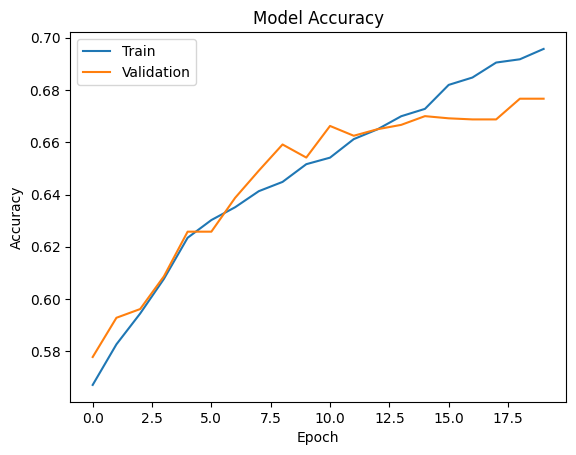

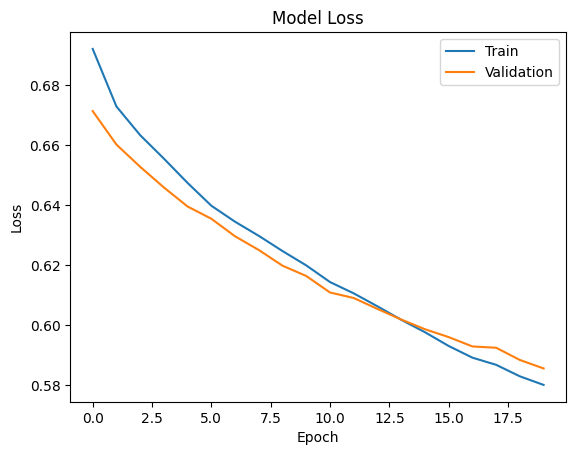

In [ ]:
import matplotlib.pyplot as plt
#Accuracy & Loss Graphs

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
 [[1220  366]
 [ 597  813]]

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.77      0.72      1586
           1       0.69      0.58      0.63      1410

    accuracy                           0.68      2996
   macro avg       0.68      0.67      0.67      2996
weighted avg       0.68      0.68      0.68      2996



In [ ]:
#for upgrading
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(14,)))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#DEMO

In [ ]:

import numpy as np

# Pick a random sample from test set
index = np.random.randint(0, len(X_test))

sample = X_test[index].reshape(1, -1)
true_label = y_test.iloc[index]

# Predict
prediction = model.predict(sample)
predicted_label = int(prediction > 0.5)

print("Predicted Value:", prediction[0][0])
print("Predicted Class:", predicted_label)
print("Actual Class:", true_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted Value: 0.5064235
Predicted Class: 1
Actual Class: 1


/tmp/ipykernel_1820/4056161265.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_label = int(prediction > 0.5)


In [ ]:
for i in range(5):
    idx = np.random.randint(0, len(X_test))
    sample = X_test[idx].reshape(1, -1)

    pred = int(model.predict(sample) > 0.5)
    actual = y_test.iloc[idx]

    print(f"Sample {i+1}: Predicted = {pred}, Actual = {actual}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Sample 1: Predicted = 1, Actual = 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Sample 2: Predicted = 1, Actual = 0


/tmp/ipykernel_1820/1905941984.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred = int(model.predict(sample) > 0.5)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Sample 3: Predicted = 0, Actual = 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Sample 4: Predicted = 0, Actual = 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Sample 5: Predicted = 0, Actual = 1


In [ ]:
def interpret(label):
    return "Eyes Closed 😴" if label == 1 else "Eyes Open 👀"

pred = int(model.predict(sample) > 0.5)

print("Prediction:", interpret(pred))
print("Actual:", interpret(actual))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediction: Eyes Open 👀
Actual: Eyes Closed 😴


/tmp/ipykernel_1820/3008128165.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred = int(model.predict(sample) > 0.5)
